In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.formula.api as smf
from data_profiling import ProfileReport
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

In [28]:
# Ruta de la carpeta donde están los archivos
ruta = r"C:\Users\lggom\Desktop\Oil&Gas"   # <-- cámbiala

# Buscar archivos que comienzan con LLAN0095
archivos = glob.glob(os.path.join(ruta, "LLAN0095*.xlsx"))

# Leer todos y guardarlos en una lista
dfs = [pd.read_excel(file) for file in archivos]

# Si quieres unirlos en un solo dataframe:
df = pd.concat(dfs, ignore_index=True)

print(df.head())

                 Date     AMA     AMV   AVOA   AVOV    CT  DeltaP      Pd  \
0 2024-01-01 00:00:30  24.283  1718.4  130.4  320.0  14.8  1873.0  2501.1   
1 2024-01-01 00:01:30  24.320  1718.4  130.6  320.0  14.8  1872.0  2499.8   
2 2024-01-01 00:02:30  24.283  1718.4  130.4  320.0  14.8  1871.1  2499.8   
3 2024-01-01 00:03:30  24.283  1718.4  130.4  320.0  14.8  1869.6  2498.0   
4 2024-01-01 00:04:30  24.320  1718.4  130.6  320.0  14.8  1867.9  2496.3   

      Pi  PWF  RUN FREQ SETTING  RUN FREQ.  RUN STATUS  SD LAST REASON     Ti  \
0  628.1  NaN               NaN       42.0         1.0             NaN  141.8   
1  627.8  NaN               NaN       42.0         1.0             NaN  141.8   
2  628.7  NaN               NaN       42.0         1.0             NaN  141.8   
3  628.4  NaN               NaN       42.0         1.0             NaN  140.0   
4  628.4  NaN               NaN       42.0         1.0             NaN  140.0   

      Tm     VX  
0  188.6  0.326  
1  188.6  0.29

In [29]:
#Guardar csv
df.to_csv("LLAN0095_total.csv", index=False, encoding="utf-8")

In [2]:
df_original = pd.read_csv("LLAN0095_total.csv")

In [3]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949041 entries, 0 to 949040
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              949041 non-null  object 
 1   AMA               940452 non-null  float64
 2   AMV               940452 non-null  float64
 3   AVOA              940422 non-null  float64
 4   AVOV              940422 non-null  float64
 5   CT                940427 non-null  float64
 6   DeltaP            940372 non-null  float64
 7   Pd                940372 non-null  float64
 8   Pi                940372 non-null  float64
 9   PWF               0 non-null       float64
 10  RUN FREQ SETTING  366 non-null     float64
 11  RUN FREQ.         940417 non-null  float64
 12  RUN STATUS        947449 non-null  float64
 13  SD LAST REASON    416 non-null     float64
 14  Ti                940374 non-null  float64
 15  Tm                940373 non-null  float64
 16  VX                94

In [4]:
df_original['Date'] = pd.to_datetime(df_original['Date'])
print(f"Date range in data: {df_original['Date'].min()} to {df_original['Date'].max()}")

Date range in data: 2024-01-01 00:00:30 to 2026-04-25 00:40:07


In [5]:
df_original

,Date,AMA,AMV,AVOA,AVOV,CT,DeltaP,Pd,Pi,PWF,RUN FREQ SETTING,RUN FREQ.,RUN STATUS,SD LAST REASON,Ti,Tm,VX
0,2024-01-01 00:00:30,24.283,1718.4,130.4,320.0,14.8,1873.0,2501.1,628.1,NaN,NaN,42.0,1.0,NaN,141.8,188.6,0.326
1,2024-01-01 00:01:30,24.320,1718.4,130.6,320.0,14.8,1872.0,2499.8,627.8,NaN,NaN,42.0,1.0,NaN,141.8,188.6,0.298
2,2024-01-01 00:02:30,24.283,1718.4,130.4,320.0,14.8,1871.1,2499.8,628.7,NaN,NaN,42.0,1.0,NaN,141.8,188.6,0.267
3,2024-01-01 00:03:30,24.283,1718.4,130.4,320.0,14.8,1869.6,2498.0,628.4,NaN,NaN,42.0,1.0,NaN,140.0,188.6,0.310
4,2024-01-01 00:04:30,24.320,1718.4,130.6,320.0,14.8,1867.9,2496.3,628.4,NaN,NaN,42.0,1.0,NaN,140.0,188.6,0.272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949036,2025-12-31 23:55:30,25.320,1843.7,130.4,358.0,9.8,1902.9,2498.6,595.7,NaN,NaN,45.0,1.0,NaN,140.4,200.3,0.197
949037,2025-12-31 23:56:30,25.359,1843.7,130.6,358.0,9.9,1903.5,2498.6,595.1,NaN,NaN,45.0,1.0,NaN,140.4,200.3,0.232
949038,2025-12-31 23:57:31,25.379,1843.7,130.7,358.0,9.9,1903.5,2498.8,595.3,NaN,NaN,45.0,1.0,NaN,140.4,200.5,0.137
949039,2025-12-31 23:58:30,25.359,1843.7,130.6,358.0,9.8,1903.8,2499.0,595.2,NaN,NaN,45.0,1.0,NaN,140.4,200.3,0.133


In [42]:
df = df_original[['Date','AMA', 'AMV', 'AVOA', 'AVOV','Pd', 'Ti','Tm', 'VX']]

# Analisis estadistico

In [84]:
# Columnas
features = ['AMA', 'AMV', 'AVOA', 'AVOV', 'Ti', 'Tm', 'VX']
target = 'Pd'

# Selección
df_model = df[features + [target]].copy()

# Limpiar NaN
df_model = df_model.dropna()

# Separar X y Y
X = df_model[features]
y = df_model[target]

In [36]:
profile = ProfileReport(
    df,
    title="Reporte Estadístico",
    explorative=True
)

profile.to_file("reporte.html")

c:\Users\lggom\anaconda3\Lib\site-packages\data_profiling\utils\dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:01<00:00,  5.44it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Analisis descriptivo (calidad de los datos)

In [37]:
desc = df_model.describe().T
desc["cv"] = desc["std"] / desc["mean"]
desc["missing_%"] = df.isnull().mean() * 100
desc['skew'] = df_model.skew()
desc['kurtosis'] = df_model.kurtosis()
desc['variance'] = df_model.var()
desc['range'] = desc['max'] - desc['min']

desc = desc.transpose()

round(desc,2)

,AMA,AMV,AVOA,AVOV,Ti,Tm,VX,Pd
count,938238.00,938238.00,938238.00,938238.00,938238.00,938238.00,938238.00,938238.00
mean,21.99,1845.50,113.72,357.16,142.13,176.62,0.22,2474.15
std,3.64,200.38,19.11,39.85,9.29,21.83,0.08,180.56
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,19.24,1843.70,99.10,358.00,140.50,156.90,0.17,2486.40
50%,19.57,1843.70,100.80,358.00,141.20,161.70,0.20,2491.70
75%,25.16,1843.70,130.00,358.00,143.10,200.30,0.26,2501.10
max,77.13,2472.00,414.20,480.00,249.00,274.60,1.23,2810.50
cv,0.17,0.11,0.17,0.11,0.07,0.12,0.35,0.07
missing_%,0.91,0.91,0.91,0.91,0.91,0.91,0.91,0.91


In [38]:
print(desc)

                     AMA            AMV           AVOA           AVOV  \
count      938238.000000  938238.000000  938238.000000  938238.000000   
mean           21.992831    1845.503491     113.723578     357.162403   
std             3.644406     200.378218      19.109440      39.845499   
min             0.000000       0.000000       0.000000       0.000000   
25%            19.243000    1843.700000      99.100000     358.000000   
50%            19.573000    1843.700000     100.800000     358.000000   
75%            25.165000    1843.700000     130.000000     358.000000   
max            77.132000    2472.000000     414.200000     480.000000   
cv              0.165709       0.108576       0.168034       0.111561   
missing_%       0.905019       0.905019       0.908180       0.908180   
skew           -1.220629      -5.040281      -1.157591      -4.662703   
kurtosis       10.107922      53.800632       9.926889      48.162384   
variance       13.281694   40151.430187     365.170

### Histogramas

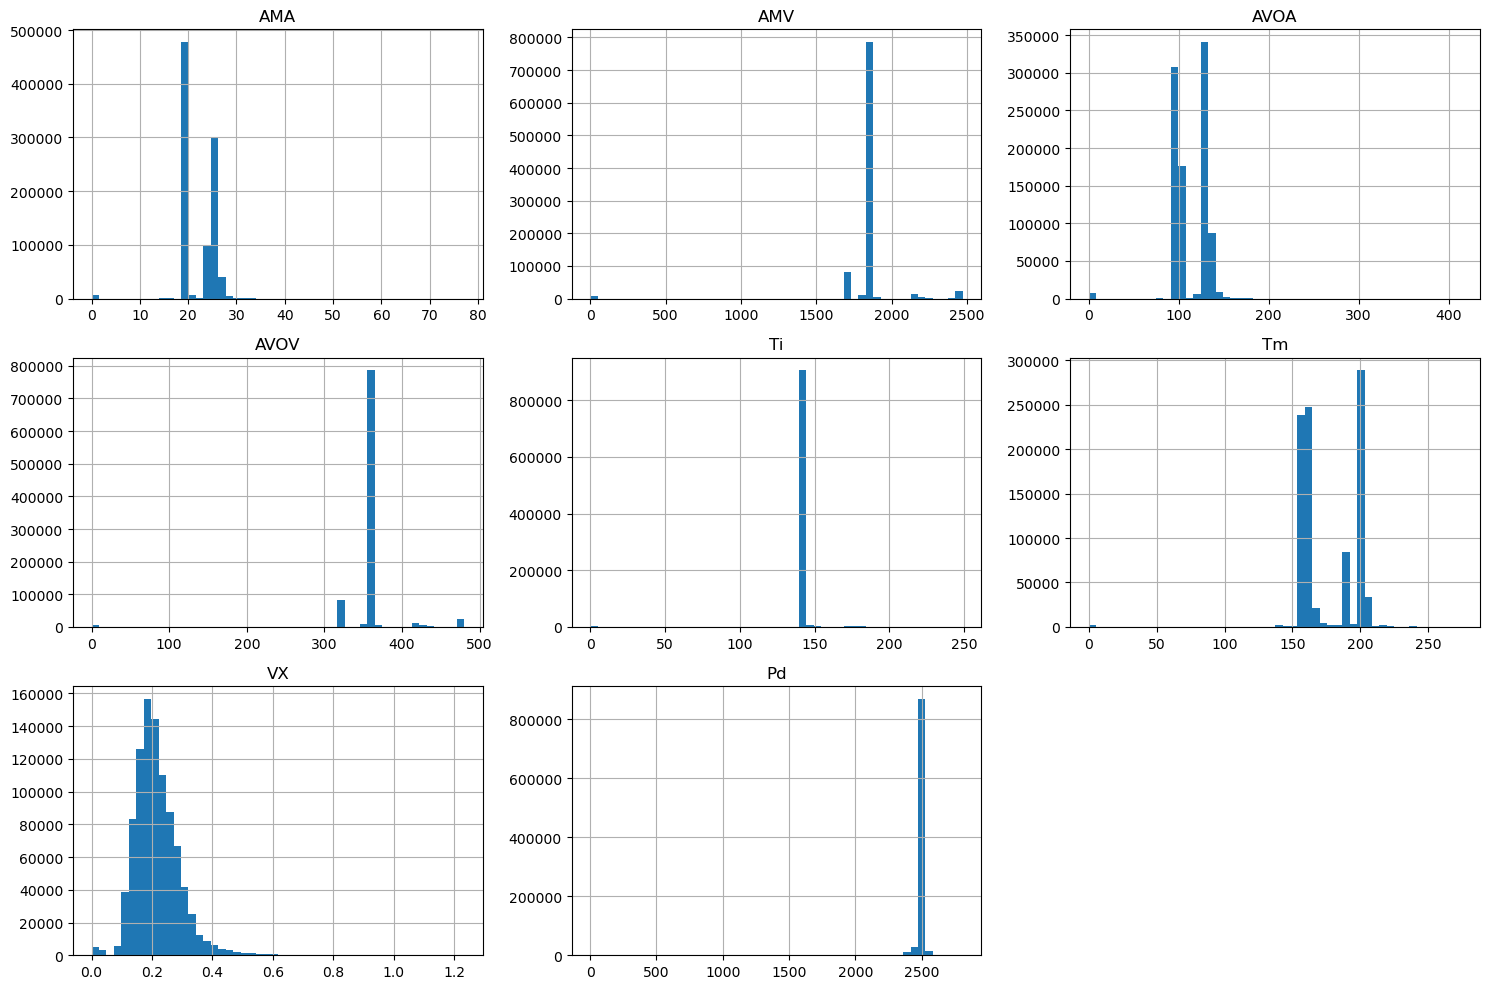

In [39]:
df_model.hist(figsize=(15,10), bins=50)
plt.tight_layout()
plt.show()

## Outliers

Deteccion de outliers usando el metodo de z-score usando outlier por encima a 3 desviaciones estandar

In [40]:
def detect_outliers_zscore(df, threshold=3):
    outlier_dict = {}
    total = len(df)
    for col in df.select_dtypes(include=np.number).columns:
        col_data = df[col].dropna()
        z_scores = np.abs(stats.zscore(col_data))
        outlier_count = (z_scores > threshold).sum()
        outlier_dict[col] = {
            'outlier_count': outlier_count,
            'outlier_pct': outlier_count / total * 100
        }
    return pd.DataFrame(outlier_dict).T

outliers = detect_outliers_zscore(df_model)
print(outliers.sort_values('outlier_pct', ascending=False))

      outlier_count  outlier_pct
AMV         31903.0     3.400310
AVOV        26189.0     2.791296
Ti          18522.0     1.974126
VX          12551.0     1.337720
Pd           9064.0     0.966066
AMA          7726.0     0.823458
AVOA         7647.0     0.815038
Tm           3240.0     0.345328


In [41]:
df[df['Ti']<50]

,Date,AMA,AMV,AVOA,AVOV,Pd,Ti,Tm,VX
5782,2024-01-05 00:36:30,24.246,1718.4,130.2,320.0,0.0,0.0,0.0,0.0
11150,2024-01-08 18:17:30,0.000,0.0,0.0,0.0,0.0,32.0,32.0,0.0
13543,2024-01-10 10:09:32,24.302,1718.4,130.5,320.0,0.0,0.0,0.0,0.0
13544,2024-01-10 10:10:30,24.339,1718.4,130.7,320.0,0.0,0.0,0.0,0.0
13545,2024-01-10 10:11:32,24.320,1718.4,130.6,320.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
864747,2025-11-02 15:43:33,25.689,1843.7,132.3,358.0,0.0,0.0,0.0,0.0
864749,2025-11-02 15:45:34,25.650,1843.7,132.1,358.0,2504.1,0.0,0.0,0.0
864750,2025-11-02 15:46:30,25.748,1843.7,132.6,358.0,0.0,0.0,0.0,0.0
864751,2025-11-02 15:47:35,25.670,1843.7,132.2,358.0,0.0,0.0,0.0,0.0


### Boxplots for Outlier Detection

Boxplots are useful for visualizing the distribution of numerical data and identifying potential outliers. An outlier is typically defined as a data point that falls outside of 1.5 times the interquartile range (IQR) from the first or third quartile.

In [42]:
# 1. Convertir fecha
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


C:\Users\lggom\AppData\Local\Temp\ipykernel_2964\3775417666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


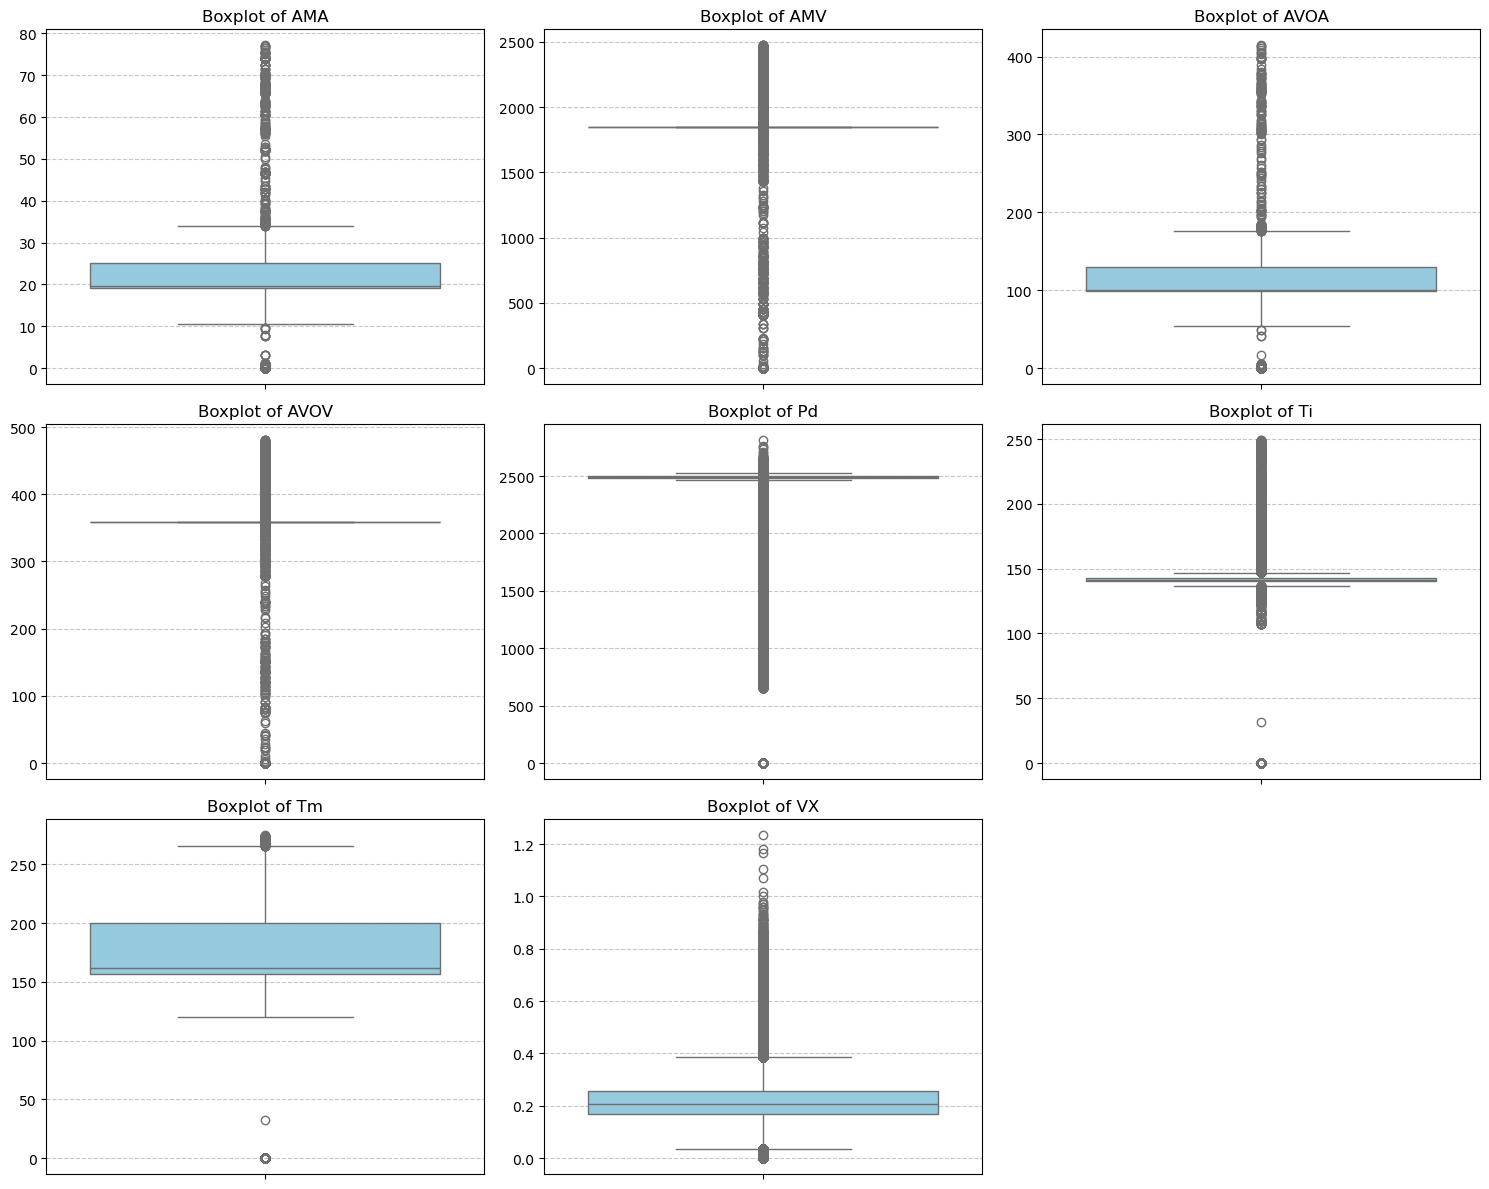

In [43]:
# Exclude the 'Date' column and the completely null '_1' column, and 'Column1' if it's constant/identifier
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Filter out 'Column1' and '_1' if they exist and are not useful for boxplots
if 'Column1' in numerical_cols: numerical_cols.remove('Column1')
if '_1' in numerical_cols: numerical_cols.remove('_1')

# Create boxplots for each numerical column

# Determine a suitable number of rows and columns for subplots
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove y-label as it's redundant with title
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Normalidad

In [44]:
normality_results = {}

for col in df.select_dtypes(include=np.number).columns:
    stat, p = stats.shapiro(df[col].dropna().sample(min(5000, len(df))))
    normality_results[col] = p

normality_df = pd.DataFrame.from_dict(normality_results, orient="index", columns=["p_value"])
print(normality_df)

           p_value
AMA   1.072959e-67
AMV   7.281614e-87
AVOA  1.830467e-68
AVOV  4.221696e-85
Pd    2.346520e-92
Ti    2.587972e-90
Tm    4.112915e-64
VX    1.169872e-44


## Linealidad (correlacion)

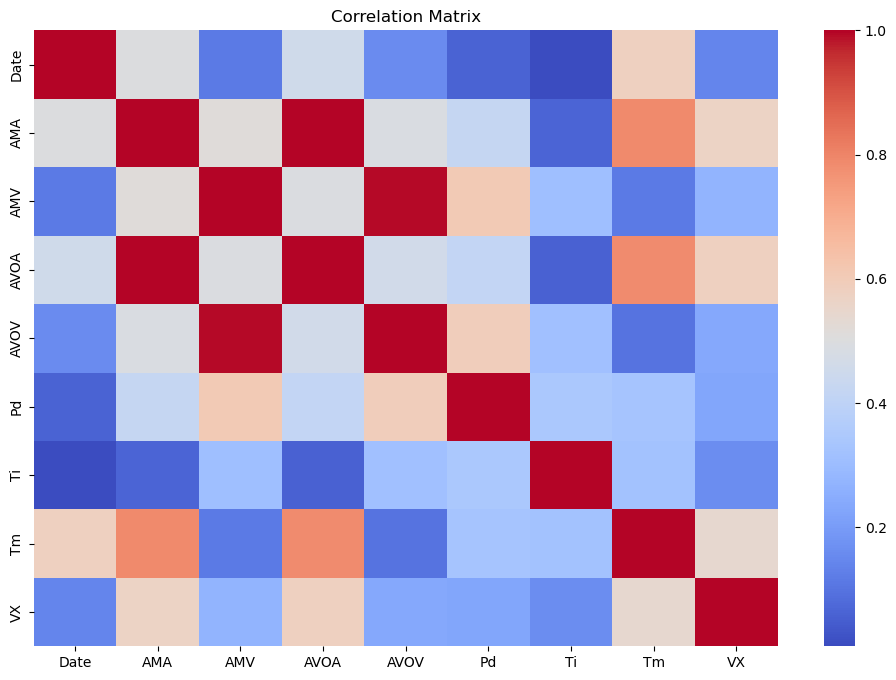

In [45]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Multicolinearidad (VIF)

In [46]:
X_vif = sm.add_constant(X.dropna())

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))
# VIF >10 problema serio

  feature          VIF
1     AMA  4932.786778
3    AVOA  4898.539909
4    AVOV  3022.591615
2     AMV  2833.569835
0   const   289.359214
6      Tm    13.653639
5      Ti     3.523477
7      VX     1.691413


Si hay alta colinearidad eliminar la que tenga menor VIF

## Modelo base (para residuals)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=False)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test - y_pred

## Homocedasticidad (escala localizacion)

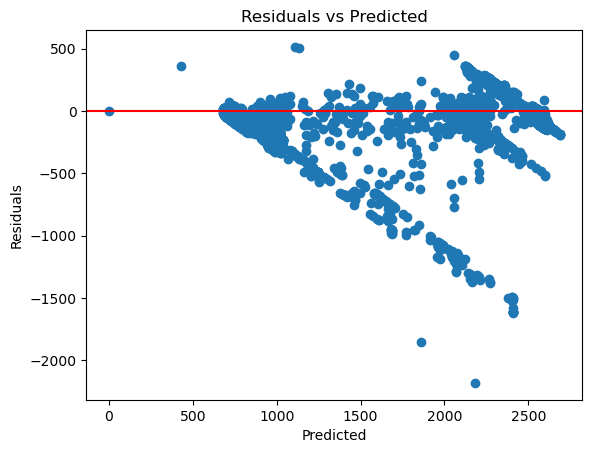

In [46]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

### Test Breusch-Pagan (requiere modelo lineal)

In [47]:
X_sm = sm.add_constant(X_train)
ols = sm.OLS(y_train, X_sm).fit()

bp_test = het_breuschpagan(ols.resid, X_sm)
labels = ["LM Statistic", "p-value", "F-value", "F p-value"]

print(dict(zip(labels, bp_test)))

{'LM Statistic': 235740.79258362929, 'p-value': 0.0, 'F-value': 49096.98191519149, 'F p-value': 0.0}


## Independencia (autocorrelacion)

In [48]:
dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)

# ~2 → ok
# <1.5 → autocorrelación

Durbin-Watson: 0.03701369337207194


## Anova (importancia estadistica)

In [49]:
anova_model = sm.OLS(y, sm.add_constant(X)).fit()
print(anova_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     Pd   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.532
Method:                 Least Squares   F-statistic:                 1.526e+05
Date:               mar, 19 may. 2026   Prob (F-statistic):               0.00
Time:                        16:48:34   Log-Likelihood:            -5.8498e+06
No. Observations:              938238   AIC:                         1.170e+07
Df Residuals:                  938230   BIC:                         1.170e+07
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        766.0674      2.168    353.315      0.0

## Importancia de variales (ML)

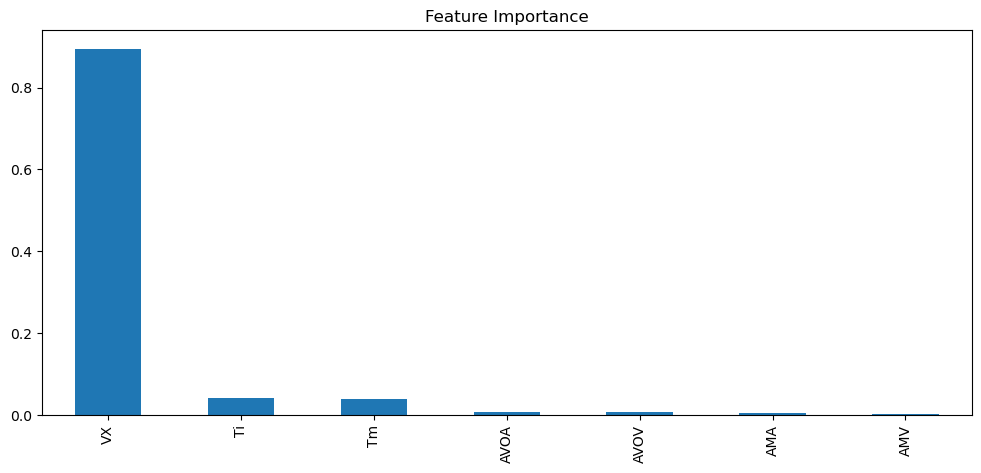

In [50]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind="bar", figsize=(12,5))
plt.title("Feature Importance")
plt.show()

In [51]:
importances

AMA     0.005657
AMV     0.003525
AVOA    0.008120
AVOV    0.007221
Ti      0.041361
Tm      0.039018
VX      0.895098
dtype: float64

## Metricas del modelo

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 5.3495141305830725
RMSE: 13.985912957185946
R2: 0.9940925747435289


## Error vs condiciones

In [ ]:
error_df = pd.DataFrame({
    "real": y_test,
    "pred": y_pred,
    "error": residuals
})

error_df["real_bin"] = pd.qcut(error_df["real"], q=5)

sns.boxplot(x="real_bin", y="error", data=error_df)
plt.xticks(rotation=45)
plt.title("Error vs Operating Range")
plt.show()

C:\Users\lggom\AppData\Local\Temp\ipykernel_25860\365066718.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Deteccion de drift

In [ ]:
train_mean = X_train.mean()
test_mean = X_test.mean()

drift = ((test_mean - train_mean) / train_mean).abs() * 100
print(drift.sort_values(ascending=False))

AVOA    0.028125
AMA     0.026289
AMV     0.024397
AVOV    0.022303
VX      0.021432
Tm      0.012447
Ti      0.006076
dtype: float64


## Conclusion automatica

In [ ]:
print("Resumen rápido:")
print(f"- Variables con alta colinealidad: {vif_data[vif_data['VIF']>10].shape[0]}")
print(f"- Variables no normales: {(normality_df['p_value']<0.05).sum()}")
print(f"- Error RMSE: {rmse}")

Resumen rápido:
- Variables con alta colinealidad: 6
- Variables no normales: 8
- Error RMSE: 13.985912957185946


# Referencia cruzada

In [43]:
features = ['AMA', 'AMV', 'AVOA', 'AVOV', 'Ti', 'Tm', 'VX']
target = 'Pd'

# =====================================================
# PREPARAR DATASET
# =====================================================

# convertir fecha
df['Date'] = pd.to_datetime(df['Date'])

# ordenar cronológicamente
df = df.sort_values('Date')

# colocar fecha como índice
df = df.set_index('Date')

# seleccionar variables
df_model = df[features + [target]].copy()

# eliminar NaN
df_model = df_model.dropna()

# separar X y Y
X = df_model[features]
y = df_model[target]

C:\Users\lggom\AppData\Local\Temp\ipykernel_24788\2284224832.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])


In [36]:
# =====================================================
# VALIDACIÓN CRUZADA TEMPORAL Random Forest
# =====================================================

tscv = TimeSeriesSplit(n_splits=5)

results = []

fold = 1

for train_index, test_index in tscv.split(X):

    # división temporal
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # =================================================
    # MODELO RANDOM FOREST
    # =================================================

    #model = RandomForestRegressor(n_estimators=100, random_state=42)
    model = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1
    )
    # entrenamiento
    model.fit(X_train, y_train)

    # predicción
    y_pred = model.predict(X_test)

    # =================================================
    # MÉTRICAS
    # =================================================

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    # fechas del fold
    train_dates = X_train.index
    test_dates = X_test.index

    # guardar resultados
    results.append({
        'Fold': fold,

        'Train Start': train_dates.min(),
        'Train End': train_dates.max(),

        'Test Start': test_dates.min(),
        'Test End': test_dates.max(),

        'Train Size': len(train_index),
        'Test Size': len(test_index),

        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    # =================================================
    # IMPRESIÓN
    # =================================================

    print("\n" + "="*60)

    print(f"FOLD {fold}")

    print("-"*60)

    print(f"TRAIN:")
    print(f"Inicio: {train_dates.min()}")
    print(f"Fin   : {train_dates.max()}")
    print(f"Datos : {len(train_index):,}")

    print()

    print(f"TEST:")
    print(f"Inicio: {test_dates.min()}")
    print(f"Fin   : {test_dates.max()}")
    print(f"Datos : {len(test_index):,}")

    print()

    print("MÉTRICAS:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    fold += 1

# =====================================================
# RESUMEN FINAL
# =====================================================

results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("RESUMEN VALIDACIÓN CRUZADA")
print("="*60)

print(results_df)

print("\nPROMEDIO MÉTRICAS")

print(
    results_df[['MAE', 'RMSE', 'R2']].mean()
)


FOLD 1
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:00:30
Fin   : 2024-06-05 23:49:30
Datos : 156,373

TEST:
Inicio: 2024-06-05 23:50:30
Fin   : 2024-10-03 16:01:30
Datos : 156,373

MÉTRICAS:
MAE  : 9.1541
RMSE : 43.2979
R2   : 0.6712

FOLD 2
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:00:30
Fin   : 2024-10-03 16:01:30
Datos : 312,746

TEST:
Inicio: 2024-10-03 16:02:30
Fin   : 2025-02-03 00:16:30
Datos : 156,373

MÉTRICAS:
MAE  : 657.4606
RMSE : 703.9850
R2   : -77.9558

FOLD 3
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:00:30
Fin   : 2025-02-03 00:16:30
Datos : 469,119

TEST:
Inicio: 2025-02-03 00:17:30
Fin   : 2025-09-08 02:14:30
Datos : 156,373

MÉTRICAS:
MAE  : 39.3220
RMSE : 106.0061
R2   : 0.7208

FOLD 4
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:00:30
Fin   : 2025-09-08 02:14:30
Datos : 625,492

T

In [44]:
# =====================================================
# VALIDACIÓN CRUZADA TEMPORAL GBR
# =====================================================

tscv = TimeSeriesSplit(n_splits=5)

results = []

fold = 1

for train_index, test_index in tscv.split(X):

    # división temporal
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # =================================================
    # MODELO GRADIENT BOOSTING
    # =================================================

    gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
    gbr.fit(X_train, y_train)

    y_pred_gbr = gbr.predict(X_test)

    # =================================================
    # MÉTRICAS
    # =================================================

    mae = mean_absolute_error(y_test, y_pred_gbr)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred_gbr)
    )

    r2 = r2_score(y_test, y_pred_gbr)

    # fechas del fold
    train_dates = X_train.index
    test_dates = X_test.index

    # guardar resultados
    results.append({
        'Fold': fold,

        'Train Start': train_dates.min(),
        'Train End': train_dates.max(),

        'Test Start': test_dates.min(),
        'Test End': test_dates.max(),

        'Train Size': len(train_index),
        'Test Size': len(test_index),

        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    # =================================================
    # IMPRESIÓN
    # =================================================

    print("\n" + "="*60)

    print(f"FOLD {fold}")

    print("-"*60)

    print(f"TRAIN:")
    print(f"Inicio: {train_dates.min()}")
    print(f"Fin   : {train_dates.max()}")
    print(f"Datos : {len(train_index):,}")

    print()

    print(f"TEST:")
    print(f"Inicio: {test_dates.min()}")
    print(f"Fin   : {test_dates.max()}")
    print(f"Datos : {len(test_index):,}")

    print()

    print("MÉTRICAS:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    fold += 1

# =====================================================
# RESUMEN FINAL
# =====================================================

results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("RESUMEN VALIDACIÓN CRUZADA")
print("="*60)

print(results_df)

print("\nPROMEDIO MÉTRICAS")

print(
    results_df[['MAE', 'RMSE', 'R2']].mean()
)


FOLD 1
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:00:30
Fin   : 2024-06-05 23:49:30
Datos : 156,373

TEST:
Inicio: 2024-06-05 23:50:30
Fin   : 2024-10-03 16:01:30
Datos : 156,373

MÉTRICAS:
MAE  : 9.6028
RMSE : 20.5522
R2   : 0.9259

FOLD 2
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:00:30
Fin   : 2024-10-03 16:01:30
Datos : 312,746

TEST:
Inicio: 2024-10-03 16:02:30
Fin   : 2025-02-03 00:16:30
Datos : 156,373

MÉTRICAS:
MAE  : 445.9367
RMSE : 493.0559
R2   : -37.7302

FOLD 3
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:00:30
Fin   : 2025-02-03 00:16:30
Datos : 469,119

TEST:
Inicio: 2025-02-03 00:17:30
Fin   : 2025-09-08 02:14:30
Datos : 156,373

MÉTRICAS:
MAE  : 28.7385
RMSE : 93.4212
R2   : 0.7831

FOLD 4
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:00:30
Fin   : 2025-09-08 02:14:30
Datos : 625,492

TE


Fold 1
Test Inicio: 2024-06-05 23:50:30
Test Fin   : 2024-10-03 16:01:30

Fold 2
Test Inicio: 2024-10-03 16:02:30
Test Fin   : 2025-02-03 00:16:30

Fold 3
Test Inicio: 2025-02-03 00:17:30
Test Fin   : 2025-09-08 02:14:30

Fold 4
Test Inicio: 2025-09-08 02:15:34
Test Fin   : 2025-12-27 21:59:30

Fold 5
Test Inicio: 2025-12-27 22:00:30
Test Fin   : 2026-04-23 21:42:30


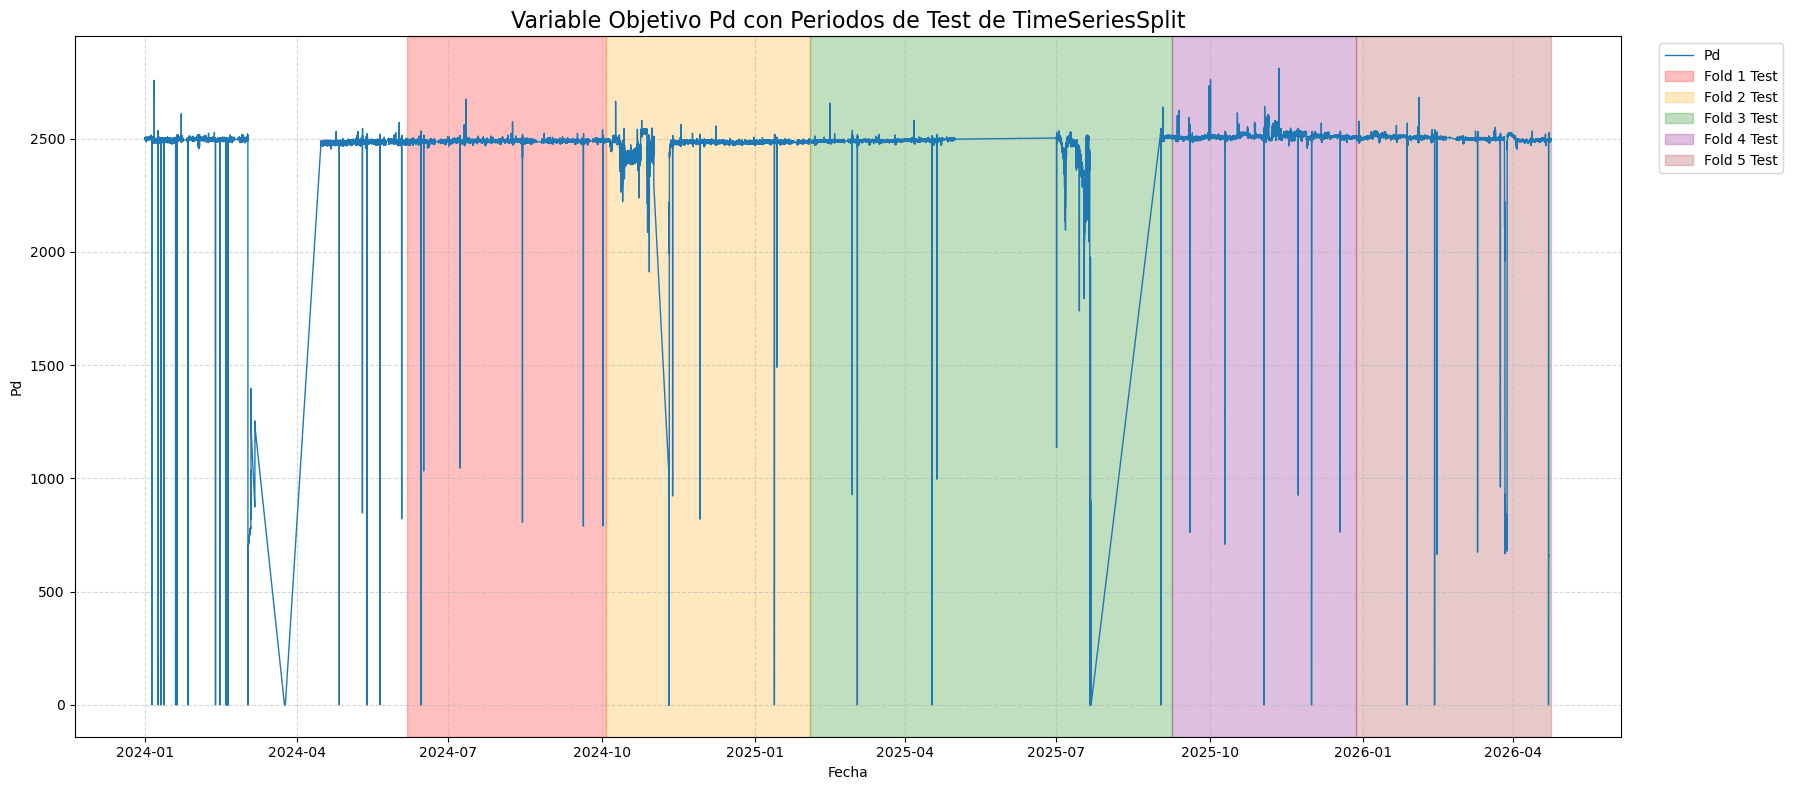

In [60]:
plt.figure(figsize=(18,8))
# serie completa
plt.plot(y.index,y.values,linewidth=1,label='Pd')

# COLORES PARA FOLDS
colors = ['red','orange','green','purple','brown']

# MARCAR PERIODOS TEST
for fold, (_, test_index) in enumerate(tscv.split(X), start=1):

    test_dates = y.iloc[test_index].index
    test_start = test_dates.min()
    test_end = test_dates.max()
    # sombrear periodo test
    plt.axvspan(test_start,test_end,alpha=0.25,color=colors[fold-1],label=f'Fold {fold} Test')
    # imprimir fechas
    print(f'\nFold {fold}')
    print(f'Test Inicio: {test_start}')
    print(f'Test Fin   : {test_end}')

# ESTILO

plt.title(
    'Variable Objetivo Pd con Periodos de Test de TimeSeriesSplit',
    fontsize=16
)

plt.xlabel('Fecha')
plt.ylabel('Pd')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1),loc='upper left')
plt.tight_layout()
plt.show()

# Revision data

### Time Series Plots with Date Range Filtering

To visualize the trends of each numerical variable over time and allow for filtering by a specific date range, we will:
1. Ensure the 'Date' column is in datetime format.
2. Provide input fields for defining the start and end dates for filtering.
3. Generate line plots for each numerical column against the 'Date' column, using the filtered data.

In [ ]:
# Convert 'Date' column to datetime objects if not already converted
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date to ensure correct time series plotting
df = df.sort_values(by='Date').reset_index(drop=True)

print(f"Date range in data: {df['Date'].min()} to {df['Date'].max()}")

### Data Sampling for Visualization

Given the large number of records (over 1 million), creating plots for the entire dataset can be computationally expensive and might lead to overplotting, making patterns harder to discern. To address this, we will take a random sample of the data. This sampled dataset will be used for subsequent filtering and visualization steps, providing a quicker and clearer overview of the trends while still being representative of the overall data.

You can adjust the `sample_fraction` parameter below to change the proportion of data to be included in the sample.

#### Define Date Range for Filtering

Use the fields below to specify the start and end dates for your analysis. The plots will only show data within this selected period.

Datos graficados: 15,176


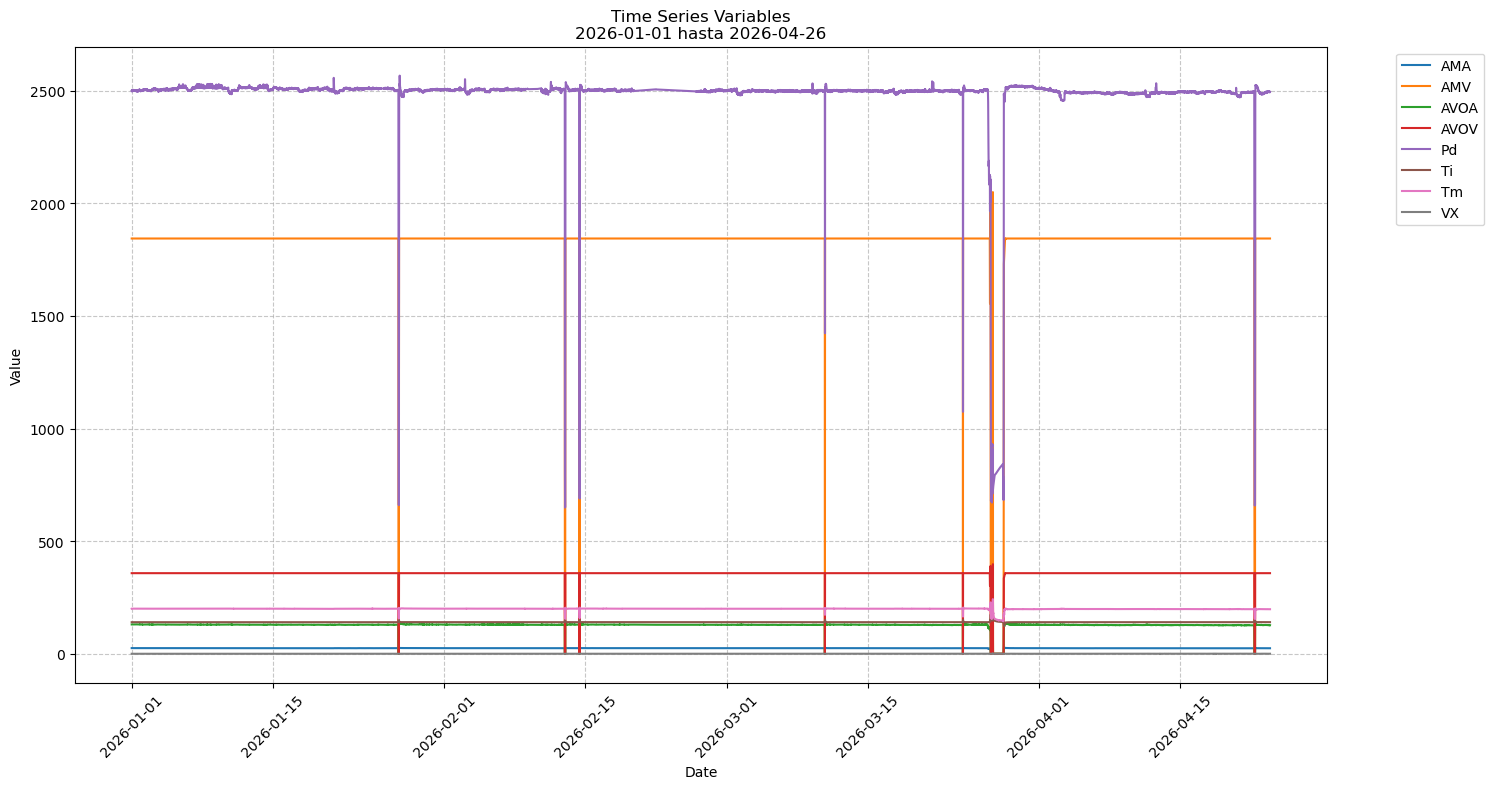

In [81]:
fecha_inicio = '2026-01-01'
fecha_fin = '2026-04-26'

# asegurar que el index sea datetime
df.index = pd.to_datetime(df.index)

# ordenar cronológicamente
df = df.sort_index()
df_filtered = df.loc[fecha_inicio:fecha_fin]

# aproximadamente 10%
step = 10

# toma cada 10 registros manteniendo orden temporal
df_filtered = df_filtered.iloc[::step]

print(f'Datos graficados: {len(df_filtered):,}')

plt.figure(figsize=(15, 8))
# columnas numéricas
numerical_cols = df_filtered.select_dtypes(
    include=['float64', 'int64']
).columns.tolist()

# =====================================================
# GRAFICAR VARIABLES
# =====================================================

for col in numerical_cols:

    sns.lineplot(
        x=df_filtered.index,
        y=df_filtered[col],
        label=col
    )

plt.title(
    f'Time Series Variables\n{fecha_inicio} hasta {fecha_fin}'
)
plt.xlabel('Date')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [56]:
# Enter the start and end dates in YYYY-MM-DD HH:MM:SS format.
start_date_str = "2025-07-01 10:00:00" # @param {type:"string"}
end_date_str = "2025-07-01 23:30:00" # @param {type:"string"}

# Ensure 'Date' column in df_csv is datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Convert string dates to datetime objects for filtering
start_date = pd.to_datetime(start_date_str)
end_date = pd.to_datetime(end_date_str)

# Filter the DataFrame based on the selected date range
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

print(f"Filtered data from {df_filtered['Date'].min()} to {df_filtered['Date'].max()}")
print(f"Number of rows after filtering: {len(df_filtered)}")

Filtered data from 2025-07-01 10:00:33 to 2025-07-01 23:29:31
Number of rows after filtering: 808


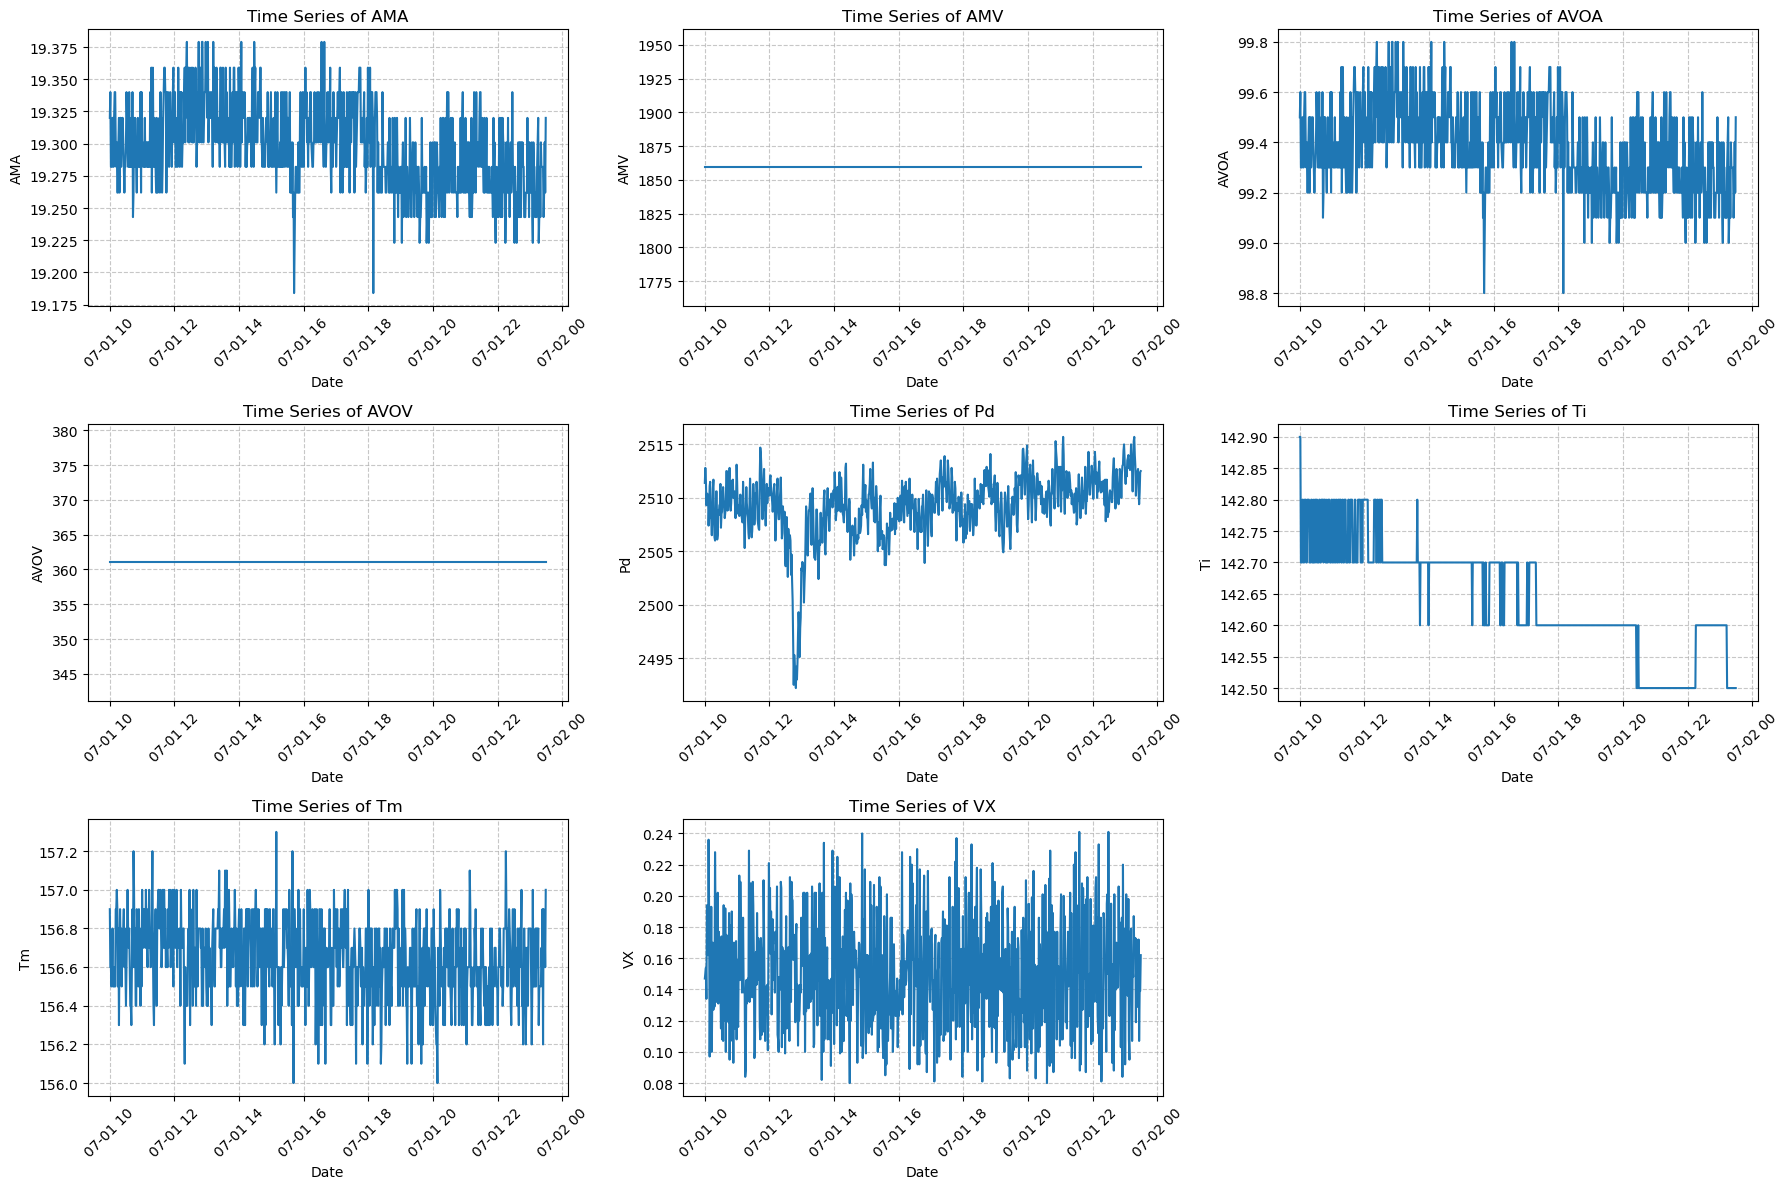

In [57]:
# Identify numerical columns, excluding 'Column1' and '_1' as they were deemed not useful
numerical_cols_for_plot = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Column1' in numerical_cols_for_plot: numerical_cols_for_plot.remove('Column1')
if '_1' in numerical_cols_for_plot: numerical_cols_for_plot.remove('_1')

# Determine a suitable number of rows and columns for subplots
n_cols = 3
n_rows = (len(numerical_cols_for_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(numerical_cols_for_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.lineplot(x='Date', y=col, data=df_filtered)
    plt.title(f'Time Series of {col}')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Broader Date Range Filtering

To manage larger date ranges more efficiently, use the fields below to apply an initial broad filter to your dataset. This creates `df_broad_filtered`, which can then be further refined by the more granular date range selection below.

In [58]:
# Enter the start and end dates for the broad filter in YYYY-MM-DD HH:MM:SS format.
start_date_broad_str = "2024-12-10 00:00:00" # @param {type:"string"}
end_date_broad_str = "2025-12-16 23:59:59" # @param {type:"string"}

# Convert string dates to datetime objects
start_date_broad = pd.to_datetime(start_date_broad_str)
end_date_broad = pd.to_datetime(end_date_broad_str)

# Filter the original DataFrame based on the broad date range
df_broad_filtered = df[(df['Date'] >= start_date_broad) & (df['Date'] <= end_date_broad)].copy()

print(f"Broadly filtered data from {df_broad_filtered['Date'].min()} to {df_broad_filtered['Date'].max()}")
print(f"Number of rows after broad filtering: {len(df_broad_filtered)}")

Broadly filtered data from 2024-12-10 00:00:30 to 2025-12-16 23:59:30
Number of rows after broad filtering: 374702


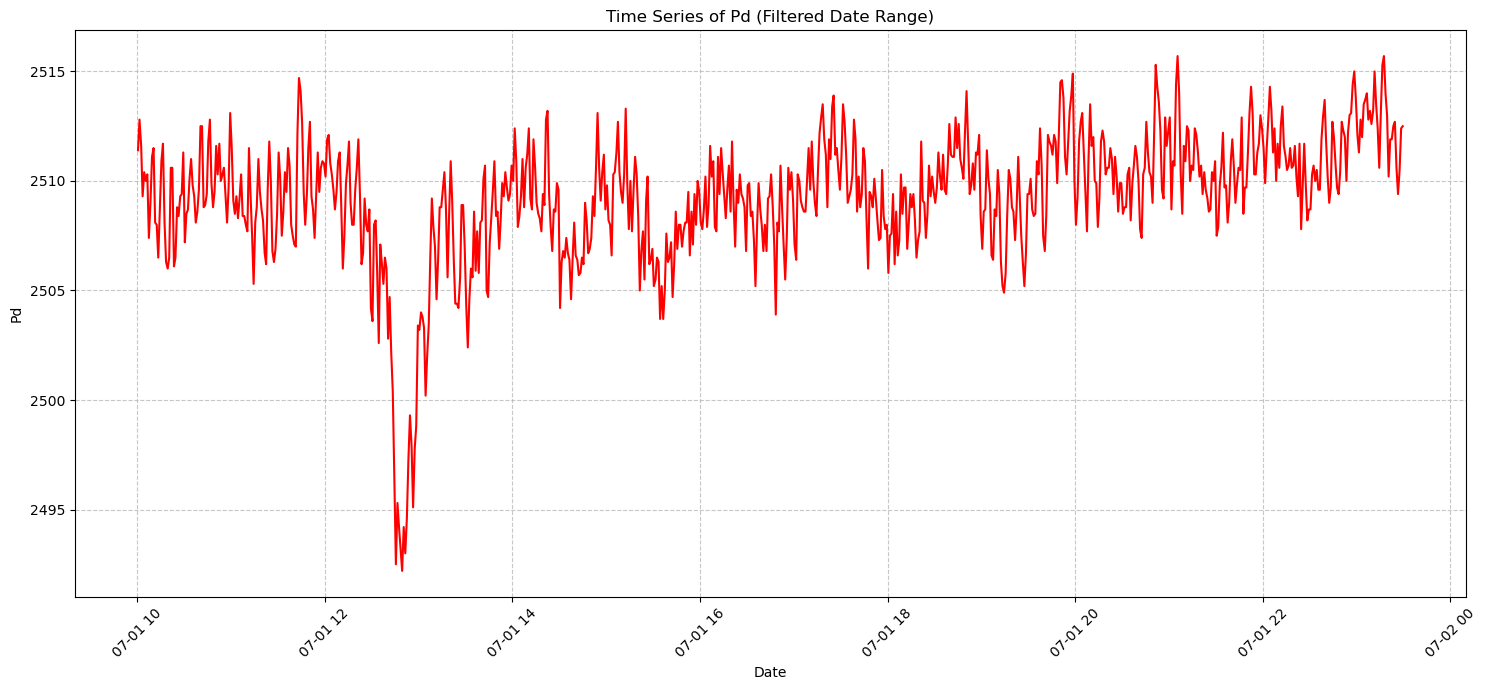

In [59]:
variable_to_plot = 'Pd'

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y=variable_to_plot, data=df_filtered, color='red')
plt.title(f'Time Series of {variable_to_plot} (Filtered Date Range)')
plt.xlabel('Date')
plt.ylabel(variable_to_plot)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Saltos de fecha

In [60]:
# Calculo de fechas donde tenga n cantidad de minutos faltantes

df['diff_min'] = df['Date'].diff().dt.total_seconds() / 60
gaps = df[df['diff_min'] > 30].copy()
gaps['start_gap'] = df['Date'].shift(1)
gaps['end_gap'] = df['Date']
gaps['missing_minutes'] = gaps['diff_min'] - 1

gaps = gaps[['start_gap', 'end_gap', 'missing_minutes']]

In [61]:
gaps

,start_gap,end_gap,missing_minutes
86245,2024-03-20 10:15:09,2024-03-20 10:45:22,29.216667
264005,2024-08-21 00:05:30,2024-08-21 02:21:32,135.033333
264314,2024-08-21 17:29:49,2024-08-21 18:07:42,36.883333
264995,2024-08-22 21:39:46,2024-08-22 22:14:30,33.733333
265186,2024-08-25 13:33:32,2024-08-25 14:16:29,41.950000
358359,2024-11-06 09:14:51,2024-11-06 09:52:21,36.500000
594587,2025-04-30 23:58:31,2025-07-01 00:00:34,87841.050000
624529,2025-07-24 08:10:54,2025-09-01 14:57:30,56565.600000
634206,2025-09-08 16:34:30,2025-09-08 17:14:30,39.000000
743205,2025-11-24 11:04:21,2025-11-24 11:36:58,31.616667


# Machine learning

In [56]:
# Columnas
features = ['AMA', 'AMV', 'AVOA', 'AVOV', 'Ti', 'Tm', 'VX']
target = 'Pd'

# Selección
df_model = df[features + [target]].copy()

# Limpiar NaN
df_model = df_model.dropna()

# Separar X y Y
X = df_model[features]
y = df_model[target]

In [57]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 00:00:30
Fin    : 2025-12-06 03:16:30
Datos  : 750,590

TEST
Inicio : 2025-12-06 03:17:30
Fin    : 2026-04-23 21:42:30
Datos  : 187,648


In [58]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Regresion lineal

In [59]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [60]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### SVM

In [61]:
#svr = SVR(kernel='rbf')
#svr.fit(X_train_scaled, y_train)

#y_pred_svr = svr.predict(X_test_scaled)

### Gradient Boosting

In [62]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [63]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    reg_lambda=2,
    reg_alpha=0.1,
    n_estimators=200,
    min_child_weight=1,
    max_depth=3,
    learning_rate=0.01,
    gamma=0.3,
    colsample_bytree=0.7,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

### Evaluacion

In [64]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
#evaluar(y_test, y_pred_svr, "SVR")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")

Linear Regression -> RMSE: 117.031 | R2: 0.596
Random Forest -> RMSE: 80.457 | R2: 0.809
Gradient Boosting -> RMSE: 54.051 | R2: 0.914
XGBoost -> RMSE: 55.269 | R2: 0.910


### Grafica

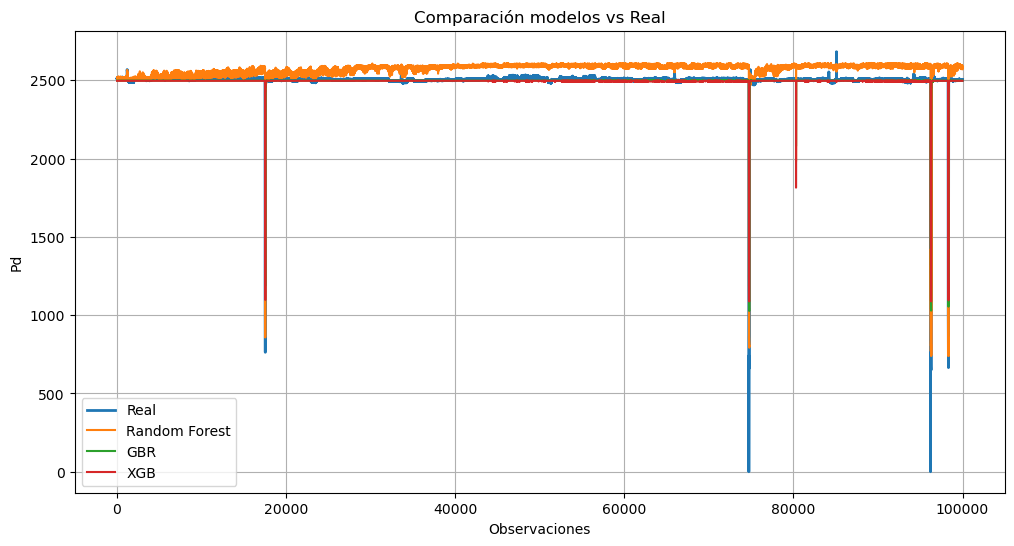

In [65]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_svr[:window_max], label='SVR')
plt.plot(y_pred_gbr[:window_max], label='GBR')
plt.plot(y_pred_xgb[:window_max], label='XGB')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Pd')
plt.grid(True)

plt.show()

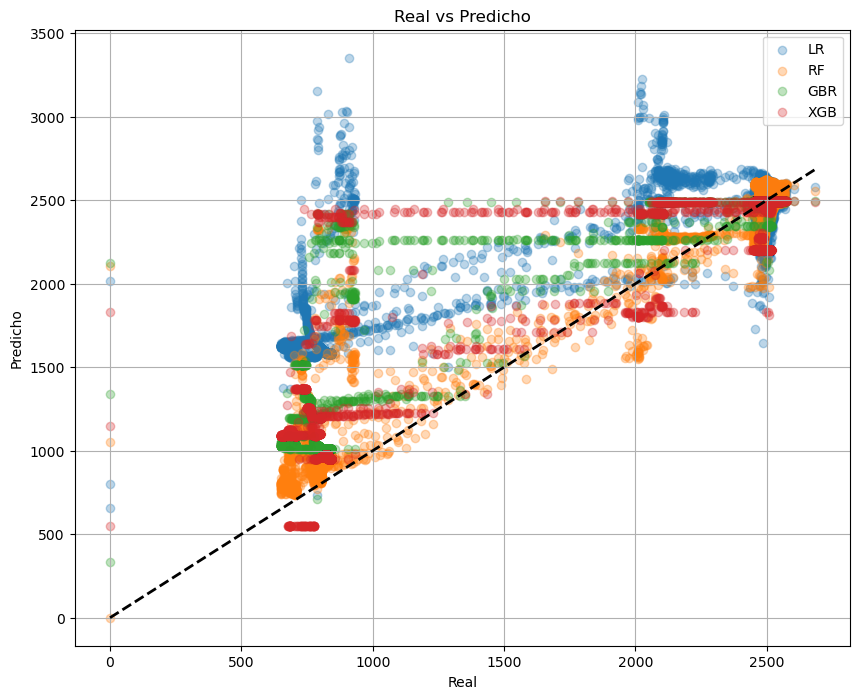

In [66]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [75]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-06 03:17:30
Fecha final: 2026-04-23 21:42:30


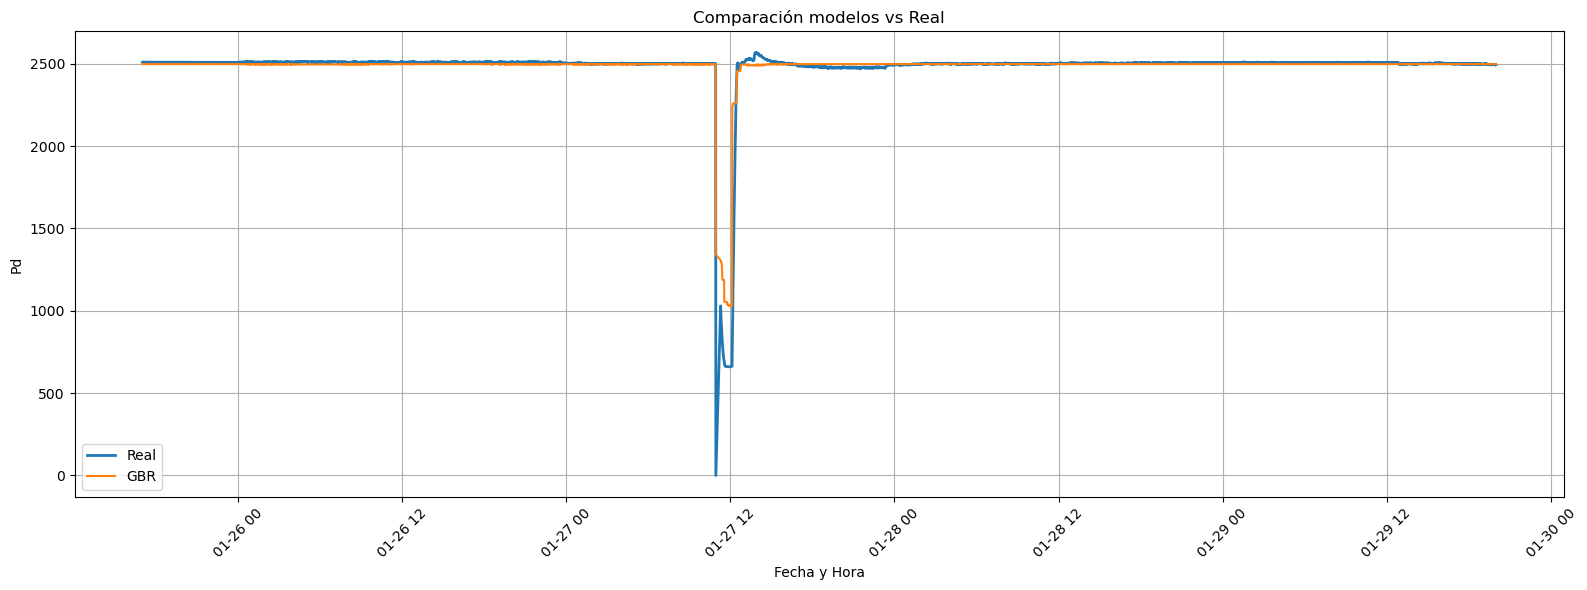

In [ ]:
inicio = '2026-01-25 17:00:00'
fin    = '2026-01-29 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
#plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
#plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
#plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
# plt.plot(y_test.index[mask], y_pred_svr[mask], label='SVR')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Pd')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Hyperpareter tunning

## Random forest Hypertunning

In [31]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [32]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,                      # número de combinaciones aleatorias
    cv=tscv,                        # validación temporal
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [33]:
# Ejecutar búsqueda aleatoria
random_search.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search.best_params_)
best_rf = random_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros encontrados:

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}


In [34]:
# Evaluar modelo afinado
y_pred_rf = best_rf.predict(X_test)
evaluar(y_test, y_pred_rf, "Random Forest Tuned")

Random Forest Tuned -> RMSE: 56.984 | R2: 0.908


## Gradient boosting hypertunning

In [37]:
tscv = TimeSeriesSplit(n_splits=5)
gbr = GradientBoostingRegressor(
    random_state=42
)
param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 1.0],
    'max_features': ['sqrt', None]
}

In [38]:
random_search_gbr = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [39]:
random_search_gbr.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_gbr.best_params_)
best_gbr = random_search_gbr.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros encontrados:

{'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.01}


In [40]:
y_pred_gbr = best_gbr.predict(X_test)
evaluar(y_test, y_pred_gbr, "Gradient Boosting Tuned")

Gradient Boosting Tuned -> RMSE: 57.987 | R2: 0.916


## XGBRegresorr hypertuning

In [52]:
tscv = TimeSeriesSplit(n_splits=5)
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

In [53]:
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [54]:
random_search_xgb.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_xgb.best_params_)
best_xgb = random_search_xgb.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros encontrados:

{'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}


In [55]:
y_pred_xgb = best_xgb.predict(X_test)
evaluar(y_test, y_pred_xgb, "XGBoost Tuned")

XGBoost Tuned -> RMSE: 55.269 | R2: 0.910


# Simulacion tiempo real

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

# Simulación de predicción en tiempo real con ventana deslizante
# Usaremos los primeros 10000 puntos para la simulación
window_max = 1000
batch_size = 1  # 10 datos cada vez
total_batches = window_max // batch_size
window_size = 100  # Ventana de 100 datos

# Preparar datos
real_data = y_test.values[:window_max]
pred_rf = y_pred_rf[:window_max]
pred_gbr = y_pred_gbr[:window_max]
pred_xgb = y_pred_xgb[:window_max]

# Configurar la figura
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_ylim(min(real_data) - 0.1, max(real_data) + 0.1)
ax.set_xlabel('Observaciones')
ax.set_ylabel('Pd')
ax.set_title('Simulación en Tiempo Real: Predicciones vs Real (Ventana Deslizante)')
ax.grid(True)

# Líneas iniciales vacías
line_real, = ax.plot([], [], label='Real', linewidth=2, color='blue')
line_rf, = ax.plot([], [], label='Random Forest', linewidth=2, color='green')
line_gbr, = ax.plot([], [], label='Gradient Boosting', linewidth=2, color='red')
line_xgb, = ax.plot([], [], label='XGBoost', linewidth=2, color='orange')

ax.legend()
# Crear un cuadro de texto para mostrar los últimos valores
textbox = ax.text(0.02, 0.98, '', transform=ax.transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                   family='monospace')
textbox.set_animated(True)

# Función de inicialización
def init():
    line_real.set_data([], [])
    line_rf.set_data([], [])
    line_gbr.set_data([], [])
    line_xgb.set_data([], [])
    textbox.set_text('')
    return line_real, line_rf, line_gbr, line_xgb, textbox

# Función de animación
def animate(frame):
    end_idx = (frame + 1) * batch_size
    start_idx = max(0, end_idx - window_size)
    
    x_data = list(range(start_idx, end_idx))
    
    line_real.set_data(x_data, real_data[start_idx:end_idx])
    line_rf.set_data(x_data, pred_rf[start_idx:end_idx])
    line_gbr.set_data(x_data, pred_gbr[start_idx:end_idx])
    line_xgb.set_data(x_data, pred_xgb[start_idx:end_idx])
    
    # Ajustar límites de la ventana
    ax.set_xlim(start_idx, end_idx)

        # Obtener últimos valores
    last_real = real_data[end_idx - 1]
    last_rf = pred_rf[end_idx - 1]
    last_gbr = pred_gbr[end_idx - 1]
    last_xgb = pred_xgb[end_idx - 1]
    
    # Actualizar el cuadro de texto
    textbox_text = f"Índice: {end_idx}\n"
    textbox_text += f"Real:     {last_real:.4f}\n"
    textbox_text += f"RF:       {last_rf:.4f}\n"
    textbox_text += f"GBR:      {last_gbr:.4f}\n"
    textbox_text += f"XGB:      {last_xgb:.4f}"
    
    textbox.set_text(textbox_text)
    
    return line_real, line_rf, line_gbr, line_xgb, textbox

# Crear la animación
anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=total_batches, interval=1000, blit=True)

# Mostrar en Jupyter
HTML(anim.to_jshtml())

Animation size has reached 21021839 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.
